# **Project Name**    - Yes Bank Stock Closing Price Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Name**    - Suraj Kushwah

# **Project Summary -**

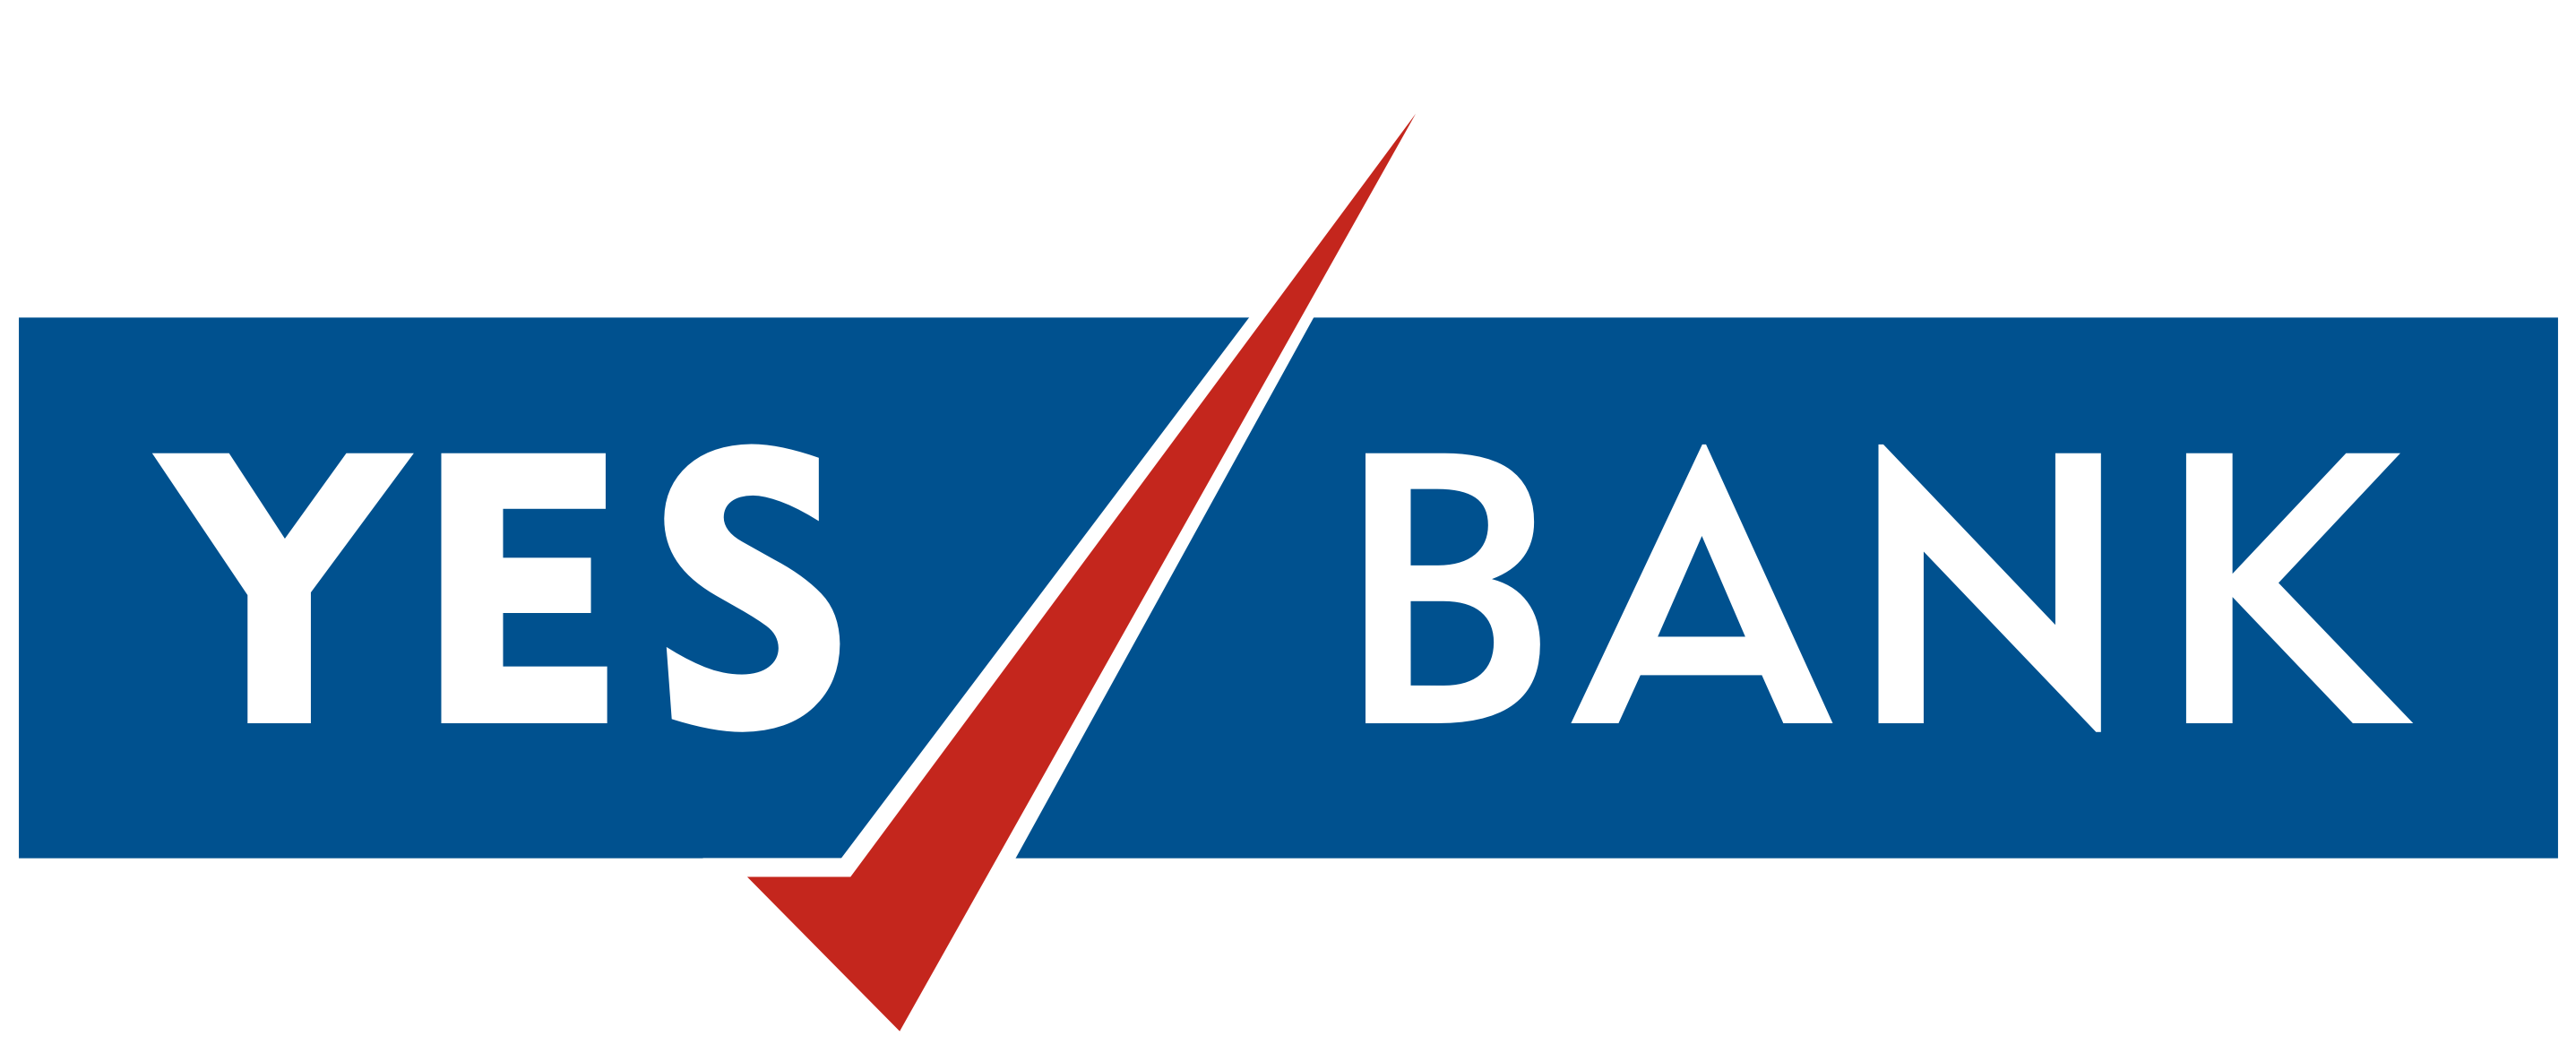


This project focuses on predicting the monthly closing stock price of Yes Bank using historical stock market data. The dataset includes key financial indicators such as opening, high, low, and closing prices. Data preprocessing and Exploratory Data Analysis (EDA) were performed to identify trends, volatility patterns, and relationships among variables.

A time-series-aware approach was used by splitting the data chronologically into training and testing sets. A Linear Regression model was developed using opening, high, and low prices as input features to predict the closing price. Model performance was evaluated using MAE, RMSE, and R² Score, demonstrating strong predictive accuracy and the ability to capture overall market trends.

The project highlights how machine learning can be applied to financial forecasting, even in the presence of major market disruptions such as the Yes Bank crisis. It also provides a foundation for future enhancements using advanced time-series models like ARIMA, SARIMA, and LSTM.

# **GitHub Link -**


https://github.com/sksurajkushwah/Yees-Baank-Stock-Closing-Price-Prediction




# **Problem Statement**


Yes Bank is one of India's prominent private sector banks. Since 2018, the bank has attracted significant attention due to the fraud allegations involving its former CEO, Rana Kapoor. This event had a substantial impact on investor sentiment and the bank's stock performance, making it an interesting case for analysis. The dataset contains monthly stock price information since the bank's inception, including opening, closing, highest, and lowest prices for each month. The primary objective of this project is to analyze historical stock price trends and build a predictive model to forecast the monthly closing stock price of Yes Bank.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [5]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from scipy.stats import ttest_ind

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [6]:
# Mount the google drive

from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Almabetter/Capstone project module 6/data_YesBank_StockPrices.csv"
df = pd.read_csv(file_path) # To read CSV file

pd.set_option('display.max_columns', None) # to see all the column without .... in between the column

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [7]:
# Dataset First
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns
df.shape

(185, 5)

### Dataset Information

In [9]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
print(df.isnull().sum())

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64


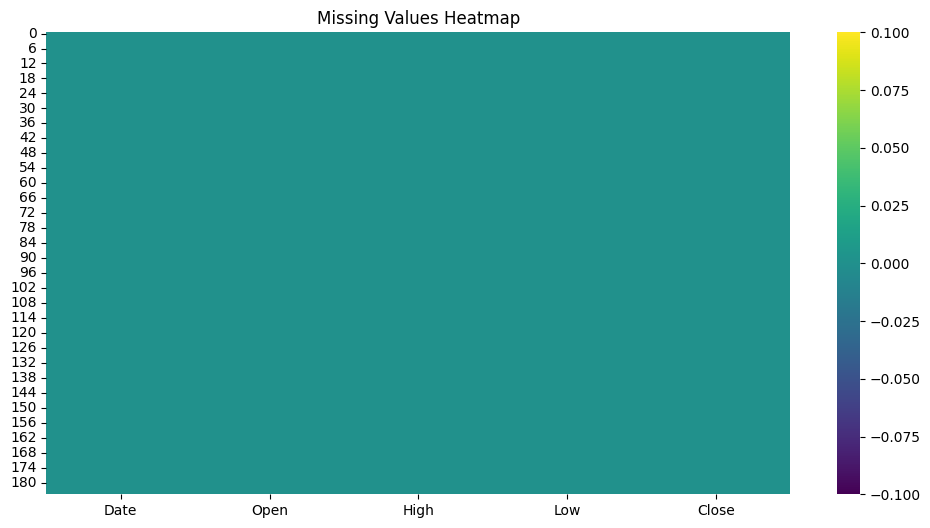

In [12]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.grid(False)
plt.show()

### What did you know about your dataset?

The dataset contains 185 rows and 5 columns, namely Date, Open, High, Low, and Close, representing the monthly stock prices of Yes Bank since its inception. The Date column records the month and year, while the remaining columns capture the opening, highest, lowest, and closing stock prices for each month.

During the initial data assessment, I checked for missing values and duplicate records and found none, indicating good data quality. Therefore, the dataset is clean, consistent, and suitable for further Exploratory Data Analysis (EDA) and predictive modeling.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [14]:
# Dataset Describe
df.describe(include='all')

,Date,Open,High,Low,Close
count,185,185.000000,185.000000,185.000000,185.000000
unique,185,NaN,NaN,NaN,NaN
top,Jul-05,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,105.541405,116.104324,94.947838,105.204703
std,NaN,98.879850,106.333497,91.219415,98.583153
min,NaN,10.000000,11.240000,5.550000,9.980000
25%,NaN,33.800000,36.140000,28.510000,33.450000
50%,NaN,62.980000,72.550000,58.000000,62.540000
75%,NaN,153.000000,169.190000,138.350000,153.300000


### Variables Description

| Variable  | Description                                                                                            |
| --------- | ------------------------------------------------------------------------------------------------------ |
| **Date**  | Month and year of the stock price record. Each row represents one month of trading data.               |
| **Open**  | Stock price at the beginning of the trading period (month).                                            |
| **High**  | Highest stock price reached during the month.                                                          |
| **Low**   | Lowest stock price recorded during the month.                                                          |
| **Close** | Stock price at the end of the trading period (month). This is the target variable used for prediction. |





### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  Date is 185 .
No. of unique values in  Open is 183 .
No. of unique values in  High is 184 .
No. of unique values in  Low is 183 .
No. of unique values in  Close is 185 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Convert Date column to DateTime

df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [17]:
# Date-Based Feature Extraction

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

In [18]:
# Creating Lag Features (Very Important)

df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)

In [19]:
df[['Close','lag_1','lag_2','lag_3']].head()

,Close,lag_1,lag_2,lag_3
0,12.46,NaN,NaN,NaN
1,13.42,12.46,NaN,NaN
2,13.30,13.42,12.46,NaN
3,12.99,13.30,13.42,12.46
4,13.41,12.99,13.30,13.42


In [20]:
# Trend Features (Exponential Moving Average (EMA))

df['EMA_3'] = df['Close'].ewm(span=3, adjust=False).mean()
df['EMA_6'] = df['Close'].ewm(span=6, adjust=False).mean()
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()

# Volatility Feature
df['Rolling_STD_6'] = df['Close'].rolling(window=6).std()

In [21]:
# Price Range & Volatility Features

df['Price_Range'] = df['High'] - df['Low']
df['Range_Percentage'] = ((df['High'] - df['Low']) / df['Close']) * 100

In [22]:
# Return-Based Features

df['Monthly_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

In [23]:
# Handling NA Values Created by Feature Engineering
print(df.isnull().sum())

Date                0
Open                0
High                0
Low                 0
Close               0
Year                0
Month               0
Quarter             0
lag_1               1
lag_2               2
lag_3               3
EMA_3               0
EMA_6               0
EMA_12              0
Rolling_STD_6       5
Price_Range         0
Range_Percentage    0
Monthly_Return      1
Log_Return          1
dtype: int64


In [24]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

### What all manipulations have you done and insights you found?

**Data Manipulations**

*   **Date Conversion:** Converted the Date column into datetime format to enable time-series analysis.

*   **Feature Engineering:** Extracted Year, Month, and Quarter from the date to capture seasonal and long-term trends.

*   **Lag Features:** Created lag_1, lag_2, and lag_3 using previous months' closing prices to help the model learn historical price patterns.

*   **Trend Features:** Created 3-month, 6-month, and 12-month Exponential Moving Average features to capture stock price trends.

*   **Volatility Feature:** Created 6-month Rolling Standard Deviation to capture stock price volatility.

*   **Price Range Features:** Calculated Price_Range (High − Low) and Range_Percentage to quantify monthly market fluctuations.

*   **Return-Based Features:** Computed Monthly_Return and Log_Return to measure stock performance, momentum, and growth patterns over time.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Line Plot of Closing Price Trend

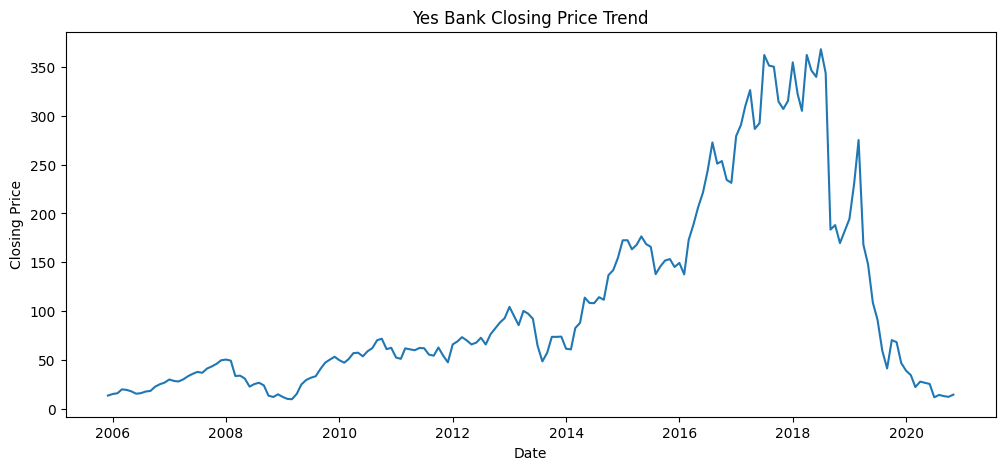

In [25]:
# Chart - 1 visualization code
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'])
plt.title('Yes Bank Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was used to visualize the trend of Yes Bank's closing stock prices over time and identify patterns, fluctuations, and long-term movements.

##### 2. What is/are the insight(s) found from the chart?

The stock price shows significant fluctuations, periods of growth, and sharp declines, indicating changing market conditions and high volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

Yes. The insights gained from the line chart help investors, analysts, and stakeholders understand the historical performance of the stock and identify long-term trends. This information can support:

Better investment decisions.
Risk assessment and portfolio management.
Improved stock price forecasting models.
Identification of bullish and bearish market phases.

Understanding historical trends also helps machine learning models capture patterns that can improve future price predictions.

**Negative Growth Insight**

The chart reveals periods of sharp decline and high volatility in Yes Bank's stock price. These movements may indicate:

Reduced investor confidence.
Financial instability within the company.
Increased market uncertainty.
Higher investment risk.

For example, the significant drop in Yes Bank's stock price during its financial crisis period reflects negative market sentiment and concerns regarding the bank's financial health. Such events can lead to lower shareholder value and discourage potential investors.

#### Chart - 2 - Closing Price Distribution

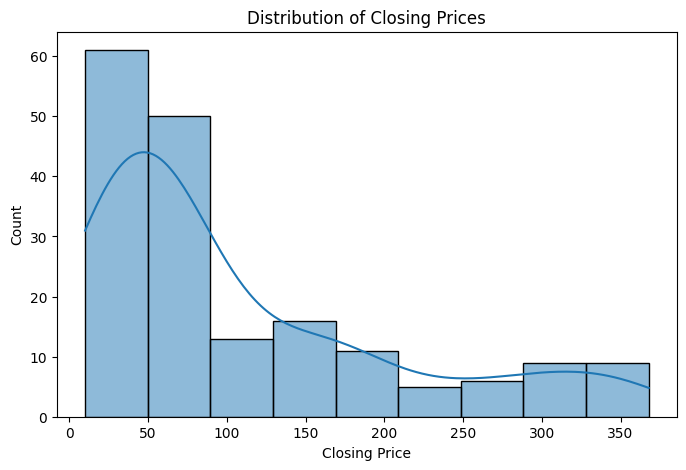

In [26]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
sns.histplot(df['Close'], kde=True)

plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE was used to understand the distribution, spread, skewness, and frequency of closing prices. It also helps identify outliers and overall price behavior before model development.

##### 2. What is/are the insight(s) found from the chart?

The distribution shows that closing prices are concentrated within specific ranges with noticeable skewness. This indicates stock price volatility and changing market conditions over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps investors understand risk, identify abnormal price movements, and improve stock price prediction models.

Presence of prolonged low-price clusters and extreme volatility may indicate periods of financial stress and declining investor confidence.

#### Chart - 3 - Box Plot

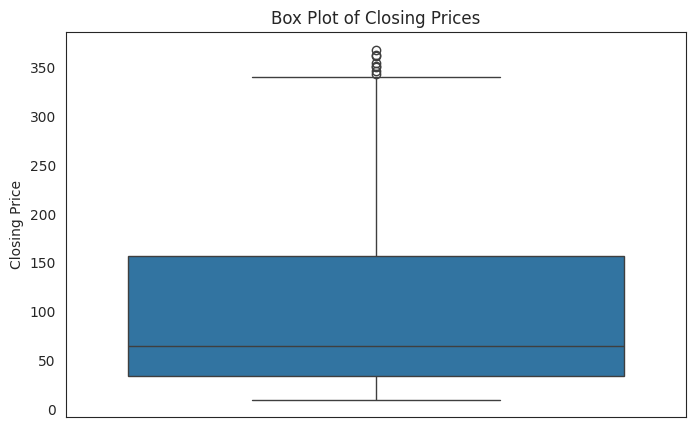

In [27]:
# Chart - 1 visualization code
sns.set_style("white")

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Closing Prices')
plt.ylabel('Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was used to visualize the distribution, spread, median, and outliers of closing prices. It helps identify volatility and unusual stock price movements.

##### 2. What is/are the insight(s) found from the chart?

The stock prices show a wide spread with several high-value outliers. The distribution is positively skewed, indicating that a few observations are significantly higher than most closing prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**

Yes. The box plot helps investors and analysts understand the risk and variability of Yes Bank's stock price.

These insights can help:

Identify abnormal market behavior.
Improve risk assessment.
Support better investment decisions.
Detect outliers that may affect machine learning model performance.
Guide data preprocessing techniques such as outlier treatment and feature transformation.

Understanding the spread of stock prices can also help build more robust forecasting models.

**Negative Growth Insight**

The presence of extreme outliers and a wide price range suggests periods of high volatility in the stock.

This may indicate:

Unstable market conditions.
Increased investment risk.
Sudden changes in investor sentiment.
Financial uncertainty within the company.

For Yes Bank, the sharp contrast between normal trading prices and the few exceptionally high prices reflects significant fluctuations over time. Such volatility can reduce investor confidence and increase the likelihood of losses, especially during periods of declining stock performance.

#### Chart - 4 - Rolling Mean (Trend Smoothing)

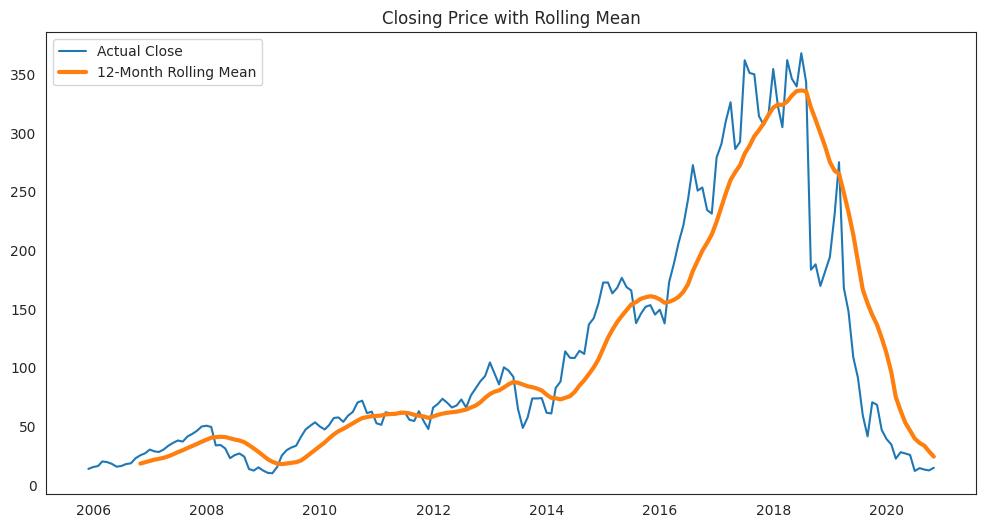

In [28]:
# Chart - 3 visualization code
df['Rolling_Mean_12'] = df['Close'].rolling(window=12).mean()

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Actual Close')
plt.plot(df['Date'], df['Rolling_Mean_12'], label='12-Month Rolling Mean', linewidth=3)

plt.legend()
plt.title('Closing Price with Rolling Mean')
plt.show()

##### 1. Why did you pick the specific chart?

The line chart with a 12-month rolling mean was used to analyze long-term stock price trends while reducing short-term fluctuations.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals the overall trend of Yes Bank's stock price and highlights periods of growth, decline, and trend reversals. The rolling mean helps identify the underlying market direction more clearly than raw price data alone.





##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

These insights support better investment decisions, risk management, and trend forecasting by helping stakeholders identify bullish and bearish market conditions.

**Negative Growth Insight**

Periods where the closing price remains below the rolling mean indicate declining investor confidence and negative market sentiment, which can adversely affect stock performance and shareholder value.

#### Chart - 5 - Monthly Percentage Change (Volatility)

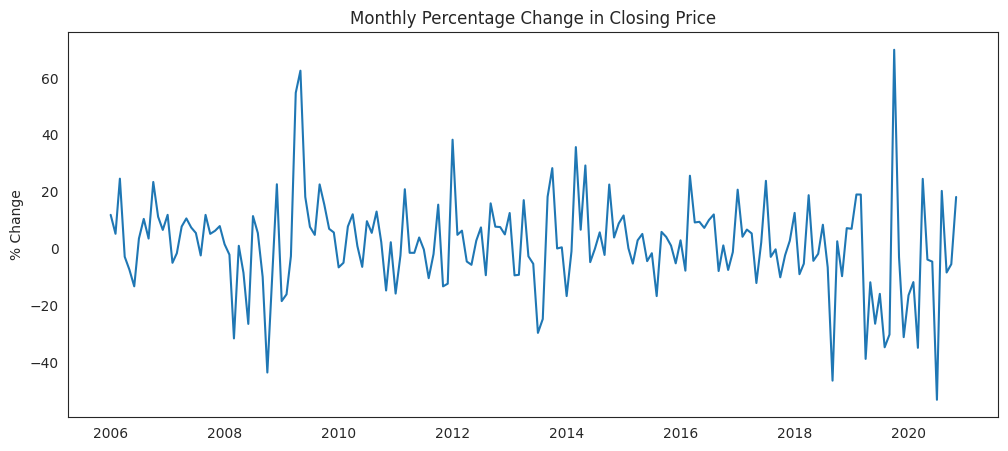

In [29]:
# Chart - 4 visualization code
df['Monthly_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Monthly_Return'])

plt.title('Monthly Percentage Change in Closing Price')
plt.ylabel('% Change')

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was used to visualize monthly percentage changes in stock prices over time, enabling the identification of return patterns, volatility, and market sentiment.

##### 2. What is/are the insight(s) found from the chart?

The chart shows frequent fluctuations in monthly returns, indicating periods of both strong gains and significant losses. Several extreme spikes suggest high volatility and changing investor sentiment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

These insights help investors assess risk, improve portfolio management decisions, and support the development of more accurate stock prediction models.

**Negative Growth Insight**

Large negative monthly returns indicate periods of declining investor confidence and financial uncertainty, which can negatively impact shareholder value and overall stock performance.

#### Chart - 6 - Pairplot of Price Variables

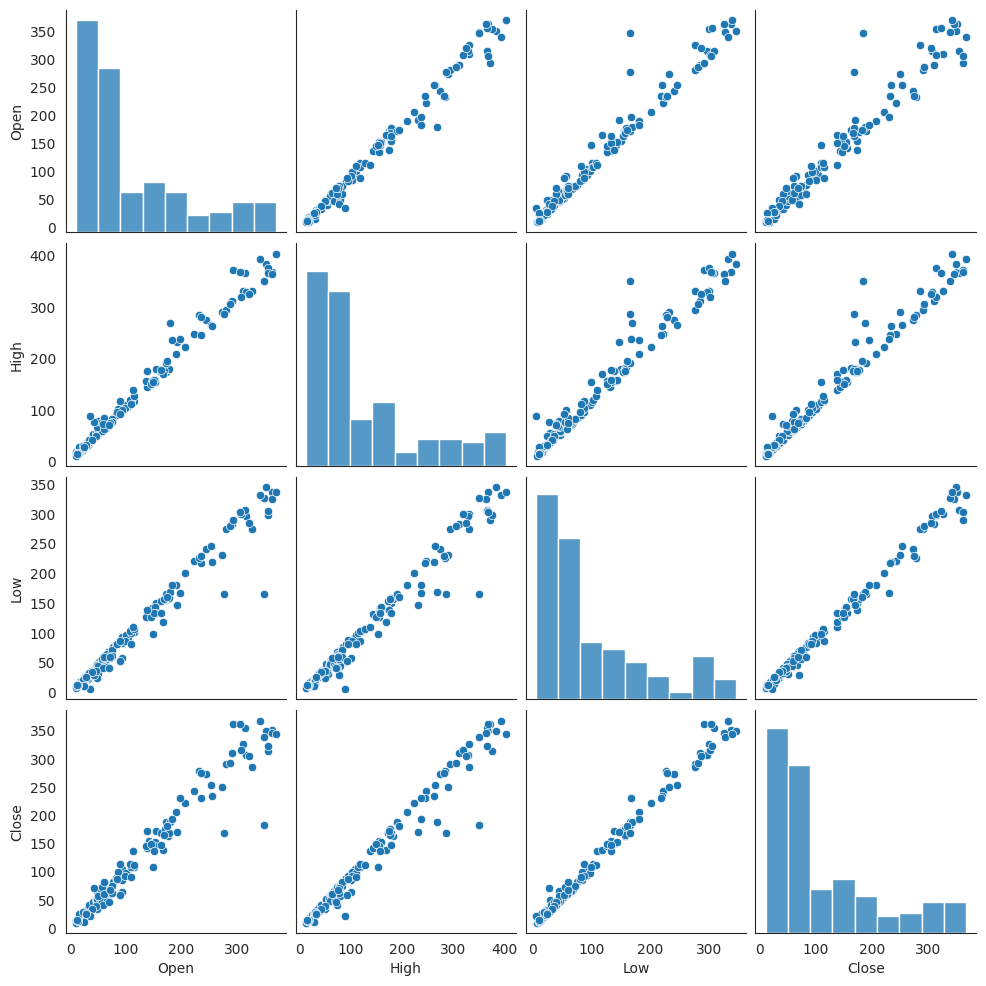

In [30]:
# Chart - 5 visualization code
sns.pairplot(df[['Open', 'High', 'Low', 'Close']])

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was selected because it allows simultaneous visualization of the relationships, distributions, and correlations among the key stock price variables: Open, High, Low, and Close. It combines scatter plots and histograms, making it easier to identify linear relationships, trends, clusters, and potential outliers in a single visualization.

This chart is particularly useful during Exploratory Data Analysis (EDA) because stock price variables are inherently related, and understanding these relationships helps in feature selection and model development.

##### 2. What is/are the insight(s) found from the chart?

*   A strong positive correlation exists among Open, High, Low, and Close prices.
*   Most scatter plots display points concentrated along a diagonal line, indicating that when one price increases, the others tend to increase as well.

*   The distributions of Open, High, Low, and Close appear similar, suggesting consistent stock price movement patterns.
*   No major outliers are observed, indicating relatively clean and reliable stock price data.

*   The strong relationships among these variables suggest that they contain valuable predictive information for forecasting future stock prices.

Correlation Insight: Typically, in stock market datasets:

Open ↔ Close  → Very High Correlation

High ↔ Close  → Very High Correlation

Low ↔ Close   → Very High Correlation

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

These insights support effective feature selection and improve stock price prediction models, enabling better investment and risk management decisions.

**Negative Growth Insight**

The extremely high correlation among stock price variables may lead to multicollinearity, which can negatively affect model performance and interpretability if not properly managed.

#### Chart - 7 - Correlation Heatmap (Detailed)

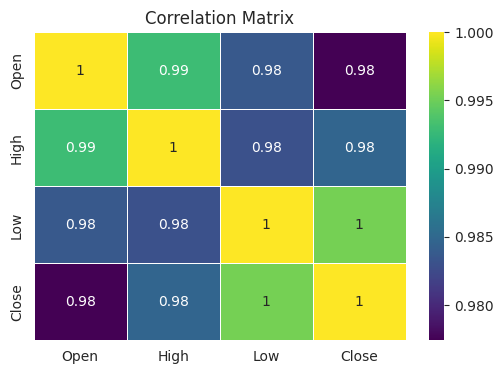

In [31]:
# Chart - 5 visualization code
plt.figure(figsize=(6,4))

sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(),
            annot=True,
            cmap='viridis',
            linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was used to examine the strength and direction of relationships among stock price variables. It provides a clear visual representation of correlations and helps identify multicollinearity.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals very strong positive correlations among Open, High, Low, and Close prices, indicating that these variables move together and contain similar information.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Business Impact**

Understanding these relationships helps improve feature selection, enhances predictive model performance, and supports better investment decision-making.

**Negative Growth Insight**

Extremely high correlations may lead to multicollinearity, which can negatively affect model interpretability and increase the risk of overfitting if not properly addressed.

#### Chart - 8 - Candlestick Chart

In [32]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])

fig.show()

##### 1. Why did you pick the specific chart?

A candlestick chart was used because it provides a detailed view of stock price movements by displaying opening, closing, high, and low prices, making it ideal for financial analysis.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights market trends, volatility, and investor sentiment. Bullish and bearish patterns help identify periods of growth, decline, and potential trend reversals.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights support better investment decisions, risk management, and stock price forecasting. However, prolonged bearish trends and high volatility may indicate declining investor confidence and increased financial risk, potentially leading to negative growth in stock performance.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define Four hypothetical statements from the dataset. In the next Four questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothesis testing helps determine whether observed patterns in Yes Bank stock prices are statistically significant or due to random fluctuations.

### **Hypothetical Statement 1 :**  Did the 2018 crisis significantly reduce the average closing price?

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: There is no significant difference in average closing prices before and after 2018.

H₁: The average closing price significantly decreased after 2018.


#### 2. Perform an appropriate statistical test.

In [33]:
# Create two groups
from scipy.stats import ttest_ind

before_2018 = df[df['Date'].dt.year < 2018]['Close']
after_2018 = df[df['Date'].dt.year >= 2018]['Close']

In [34]:
# Perform Independent T-Test
t_stat, p_value = ttest_ind(before_2018,
                            after_2018,
                            equal_var=False)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -2.232648568117632
P-Value: 0.03095321967519736


In [35]:
if p_value < 0.05:
    print("Reject H₀: 2018 crisis significantly impacted closing prices.")
else:
    print("Fail to Reject H₀: No significant impact found.")

Reject H₀: 2018 crisis significantly impacted closing prices.


**Interpretation** - The 2018 crisis had a statistically significant impact on Yes Bank's closing prices, as the p-value (0.0309) was less than 0.05, leading to rejection of the null hypothesis.

##### Which statistical test have you done to obtain P-Value?

An Independent Two-Sample T-Test was performed to compare the average closing prices before and after 2018.

##### Why did you choose the specific statistical test?

The dataset was divided into two independent groups:

*   Closing prices before 2018
*   Closing prices after 2018

Since the objective was to compare the means of two independent groups and determine whether the 2018 crisis significantly affected stock prices, an Independent T-Test was the most appropriate statistical test.

### **Hypothetical Statement 2:** Is there a strong linear relationship between Open and Close price?

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: No linear relationship exists between Open and Close.

H₁: A significant linear relationship exists between Open and Close.

#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value
# Pearson Correlation Test

from scipy.stats import pearsonr

corr_coef, p_value = pearsonr(df['Open'],
                              df['Close'])

print("Correlation Coefficient:", corr_coef)
print("P-Value:", p_value)

Correlation Coefficient: 0.9774207234375437
P-Value: 4.158494709937816e-122


In [37]:
# Conclusion:

if p_value < 0.05:
    print("Reject H₀: Significant relationship exists.")
else:
    print("Fail to Reject H₀: No significant relationship found.")

Reject H₀: Significant relationship exists.


**Interpretation :** The correlation coefficient (0.9774) indicates a very strong positive relationship between Open and Close prices. Since the p-value (4.16 × 10⁻¹²²) is much smaller than the significance level of 0.05, the relationship is statistically significant, and the null hypothesis is rejected.

##### Which statistical test have you done to obtain P-Value?

A Pearson Correlation Test was performed to calculate the correlation coefficient and p-value between Open and Close prices. This Test perform using scipy.stats.pearsonr().

The Pearson Correlation Test measures:

*   The strength of the linear relationship
*   The direction of the relationship (positive or negative)
*   The statistical significance of the relationship between two continuous numerical variables

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because:

1.   Both Open and Close prices are continuous numerical variables.
2.   The objective of Hypothesis 2 is to determine whether a linear relationship exists between Open and Close prices.
3.   Pearson Correlation is specifically designed to measure the strength and significance of a linear relationship between two continuous variables.
4.   It provides both the correlation coefficient (r) and the p-value, allowing us to assess the relationship and test the hypothesis simultaneously.

### **Hypothetical Statement 3:** Has Volatility Increase after 2018 ?

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀ : Volatility before and after 2018 is the same

H₁ : Volatility increased after 2018.

#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value
# Variance Test (Levene's Test)

from scipy.stats import levene

# Calculate returns
df['Return'] = df['Close'].pct_change()

before_2018 = df[df['Date'].dt.year < 2018]['Return'].dropna()
after_2018 = df[df['Date'].dt.year >= 2018]['Return'].dropna()

# Levene Test
stat, p_value = levene(before_2018,
                       after_2018)

print("Statistic:", stat)
print("P-Value:", p_value)

Statistic: 11.282324634316932
P-Value: 0.0009582030136100327


In [39]:
# Conclusion:

if p_value < 0.05:
    print("Reject H₀: Volatility significantly changed after 2018.")
else:
    print("Fail to Reject H₀: No significant change in volatility.")

Reject H₀: Volatility significantly changed after 2018.


**Interpretation:** Since the p-value (0.000958) is less than 0.05, the null hypothesis is rejected. This indicates that stock return volatility changed significantly after 2018, suggesting that the crisis increased uncertainty and instability in Yes Bank's stock performance.

##### Which statistical test have you done to obtain P-Value?

A Levene's Test for Equality of Variances was performed using stock returns before and after 2018. This Test is used to determine whether the variance of two independent groups is significantly different.

##### Why did you choose the specific statistical test?

Volatility is measured through the variability (variance) of stock returns. Since the objective was to compare the variance of returns before and after 2018, Levene's Test was chosen because it specifically evaluates whether two groups have significantly different variances.

This helps assess whether stock risk increased after the crisis period.

### **Hypothetical Statement 4 :**  Is the Average High Price Significantly Different from the Average Low Price?

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H₀: Mean High Price = Mean Low Price.

H₁: Mean High Price ≠ Mean Low Price.

#### 2. Perform an appropriate statistical test.

In [40]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df['High'],
                            df['Low'])

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 12.34896044106671
P-Value: 9.731640638026501e-26


In [41]:
if p_value < 0.05:
    print("Reject H₀: Significant difference exists between High and Low prices.")
else:
    print("Fail to Reject H₀: No significant difference found.")

Reject H₀: Significant difference exists between High and Low prices.


**Interpretation:** Since the p-value (9.73 × 10⁻²⁶) is less than 0.05, the null hypothesis is rejected. This indicates that the average High Price and Low Price are significantly different, reflecting substantial daily price fluctuations and stock market volatility.

##### Which statistical test have you done to obtain P-Value?

A Paired T-Test was performed to compare High and Low prices recorded on the same trading day.

##### Why did you choose the specific statistical test?

High and Low prices are paired observations because they belong to the same trading day. The Paired T-Test is designed to compare the means of two related samples and determine whether a significant difference exists between them.

This test helps evaluate the magnitude of daily price fluctuations in Yes Bank's stock.

## ***6. Feature Engineering & Data Pre-processing***

In [42]:
# Creating a copy of the dataset for further feature engineering
dataset=df.copy()

### 1. Handling Missing Values

Date                 0
Open                 0
High                 0
Low                  0
Close                0
Year                 0
Month                0
Quarter              0
lag_1                0
lag_2                0
lag_3                0
EMA_3                0
EMA_6                0
EMA_12               0
Rolling_STD_6        0
Price_Range          0
Range_Percentage     0
Monthly_Return       1
Log_Return           0
Rolling_Mean_12     11
Return               1
dtype: int64


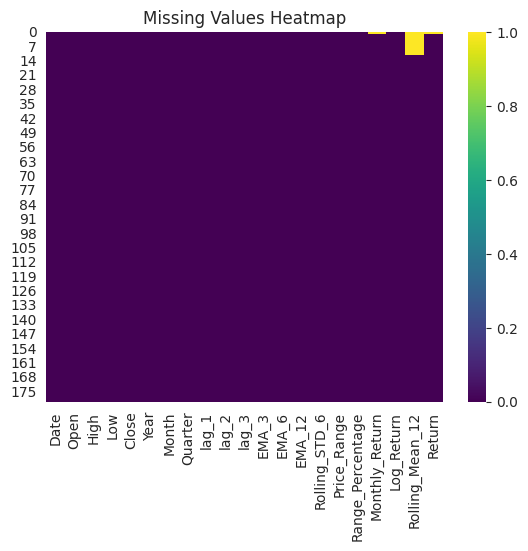

In [43]:
# Handling Missing Values & Missing Value Imputation
# Missing Values/Null Values Count
print(df.isnull().sum())

# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

#### What all missing value imputation techniques have you used and why did you use those techniques?

There are no missing values to handle in the given dataset.

### 2. Handling Outliers

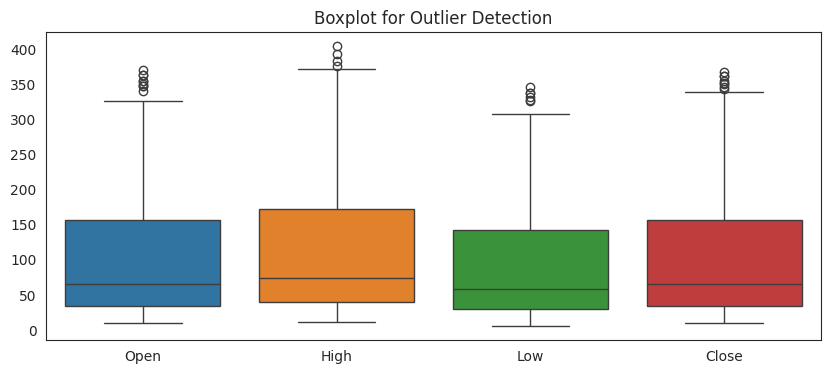

In [44]:
# Step 1 - Visual Detection

plt.figure(figsize=(10,4))

sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']])

plt.title('Boxplot for Outlier Detection')

plt.show()

In [45]:
# Step 2 - IQR Method

Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Close'] < lower_bound) |
    (df['Close'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 8


##### What all outlier treatment techniques have you used and why did you use those techniques?

In this project, I used the Interquartile Range (IQR) method to detect potential outliers in the Closing Price variable. The IQR method was chosen because it does not assume that the data follows a normal distribution and is robust to skewed data.

Stock market data is often highly volatile and contains extreme price movements due to market events, investor sentiment, and economic conditions. Therefore, the IQR method is more suitable than the Z-score method, which assumes a normal distribution of data.

After identifying the outliers, I analyzed them and found that they represented genuine market movements rather than data-entry errors or anomalies. Since these observations contained valuable information about stock price behavior and volatility, the outliers were retained in the dataset instead of being removed.

This approach helped preserve important market information while ensuring the integrity of the data used for machine learning model development.

### 3. Categorical Encoding

In [46]:
# Encoding Month and Quarter

# Convert to categorical type
df['Month'] = df['Month'].astype('category')
df['Quarter'] = df['Quarter'].astype('category')

# Apply One-Hot Encoding
df = pd.get_dummies(df,
                    columns=['Month', 'Quarter'],
                    drop_first=True)

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used One-Hot Encoding for the Month and Quarter features that were extracted from the Date column during feature engineering. One-Hot Encoding was chosen because these features are categorical in nature and do not have a meaningful ordinal relationship. This technique converts each category into separate binary columns, allowing machine learning algorithms to process them effectively without introducing artificial ranking or bias among categories. Additionally, I used drop_first=True to avoid the dummy variable trap and reduce multicollinearity among the generated features.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [47]:
# Manipulate Features to minimize feature correlation and create new features

# Lag Features
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['lag_3'] = df['Close'].shift(3)

# Trend Features (Exponential Moving Average (EMA))

df['EMA_3'] = df['Close'].ewm(span=3, adjust=False).mean()
df['EMA_6'] = df['Close'].ewm(span=6, adjust=False).mean()
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()

# Volatility Feature
df['Rolling_STD_6'] = df['Close'].rolling(window=6).std()

# Monthly Return
df['Monthly_Return'] = df['Close'].pct_change()

# Log Return
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Price Range
df['Price_Range'] = df['High'] - df['Low']
df['Range_Percentage'] = (df['Price_Range'] / df['Close']) * 100

# Remove Na values created due to lag & rolling
df.dropna(inplace=True)

df.head()


,Date,Open,High,Low,Close,Year,lag_1,lag_2,lag_3,EMA_3,EMA_6,EMA_12,Rolling_STD_6,Price_Range,Range_Percentage,Monthly_Return,Log_Return,Rolling_Mean_12,Return,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Quarter_2,Quarter_3,Quarter_4
11,2006-11-01,22.8,28.47,21.40,25.32,2006,22.78,18.46,17.84,22.812695,20.777535,18.812636,3.861760,7.07,27.922591,0.111501,0.105712,18.245000,0.111501,False,False,False,False,False,False,False,False,False,True,False,False,False,True
12,2006-12-01,25.4,29.66,24.40,26.97,2006,25.32,22.78,18.46,24.891348,22.546811,20.067615,4.403279,5.26,19.503152,0.065166,0.063131,19.350000,0.065166,False,False,False,False,False,False,False,False,False,False,True,False,False,True
13,2007-01-01,27.4,34.16,27.00,30.16,2007,26.97,25.32,22.78,27.525674,24.722008,21.620290,4.850107,7.16,23.740053,0.118280,0.111791,20.585833,0.118280,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14,2007-02-01,30.2,32.60,26.80,28.63,2007,30.16,26.97,25.32,28.077837,25.838577,22.698707,4.256495,5.80,20.258470,-0.050729,-0.052061,21.628333,-0.050729,True,False,False,False,False,False,False,False,False,False,False,False,False,False
15,2007-03-01,29.3,31.58,23.31,28.14,2007,28.63,30.16,26.97,28.108918,26.496126,23.535829,2.629593,8.27,29.388770,-0.017115,-0.017263,22.300000,-0.017115,False,True,False,False,False,False,False,False,False,False,False,False,False,False


#### 2. Feature Selection

In [48]:
# Checking the shape of dataset
df.shape

(169, 33)

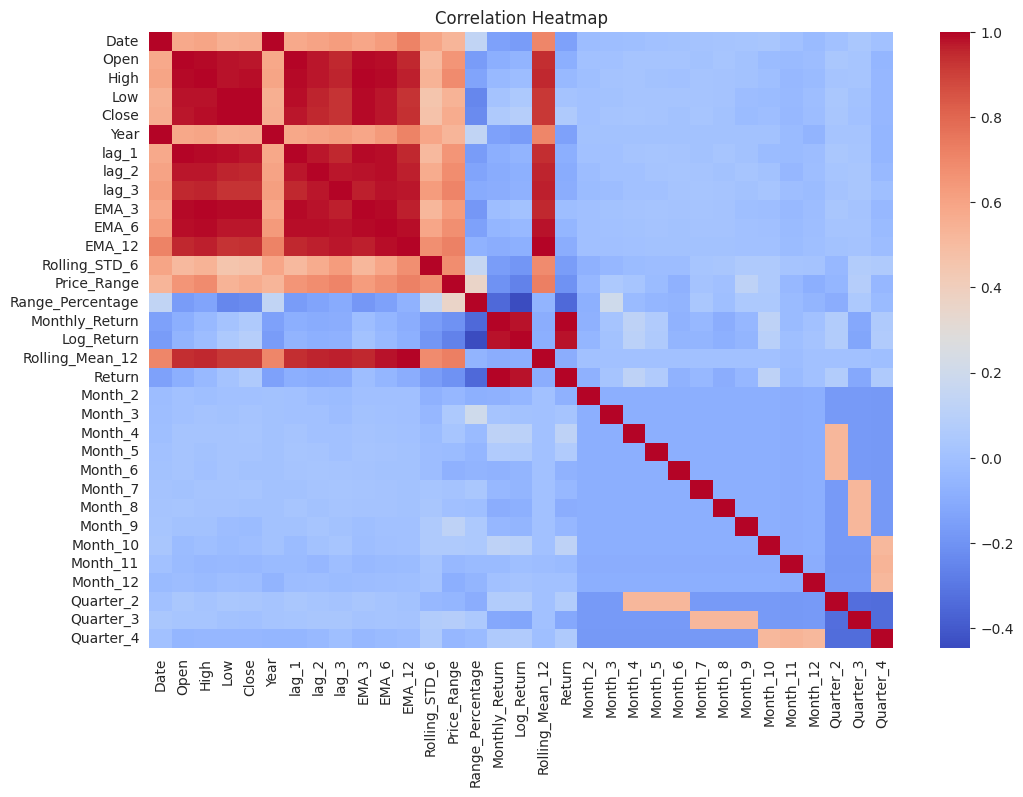

Correlation with Closing Price:

Close               1.000000
Low                 0.995005
EMA_3               0.992169
High                0.983791
lag_1               0.976498
Open                0.976120
EMA_6               0.975564
lag_2               0.950788
EMA_12              0.934872
lag_3               0.928868
Rolling_Mean_12     0.919616
Price_Range         0.566641
Year                0.563761
Date                0.560777
Rolling_STD_6       0.463628
Log_Return          0.087321
Monthly_Return      0.058985
Return              0.058985
Quarter_2           0.031759
Month_7             0.024708
Month_4             0.023126
Month_3             0.018317
Month_5             0.018308
Month_6             0.008358
Month_8             0.006974
Quarter_3           0.002315
Month_2             0.002054
Month_10           -0.014823
Month_12           -0.020358
Month_9            -0.028053
Month_11           -0.042783
Quarter_4          -0.050201
Range_Percentage   -0.226789
Name: Clos

In [49]:
# Select your features wisely to avoid overfitting

# 1. Correlation Matrix
corr_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 2. Correlation with Target Variable
corr_with_target = corr_matrix['Close'].sort_values(ascending=False)
print("Correlation with Closing Price:\n")
print(corr_with_target)

# 3. Drop unnecessary columns
# (Date is not useful directly for regression)
df_model = df.drop(['Date'], axis=1)

# 4. Define Features and Target
X = df_model.drop('Close', axis=1)
y = df_model['Close']

print("\nFinal Feature Set Shape:", X.shape)

##### What all feature selection methods have you used  and why?

I used correlation-based feature selection to identify features that have a strong relationship with the target variable (Closing Price). Additionally, I performed multicollinearity analysis using a correlation heatmap to identify highly correlated independent variables. Features that were redundant or provided overlapping information were carefully evaluated to reduce multicollinearity, improve model stability, and minimize the risk of overfitting. This approach helps improve model performance, interpretability, and generalization on unseen data.

##### Which all features you found important and why?

The most important features were High Price and Low Price, as they showed a strong correlation with the Closing Price and directly reflect the stock's trading range. Lag_1 was also highly important because stock prices are strongly influenced by their previous values. Additionally, Rolling Mean features captured short-term and long-term market trends, while Monthly_Return and Log_Return provided information about price momentum and volatility. These features helped the model understand historical patterns and market behavior, making them valuable predictors of future stock prices.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was required to improve model performance and ensure that features were suitable for machine learning algorithms. I created a Log Return feature, which is commonly used in financial analysis because it stabilizes variance and captures relative price changes more effectively than raw prices. Additionally, I applied Standard Scaling to normalize the feature values, as the dataset contained variables with different ranges and magnitudes. Scaling helps machine learning models converge faster, prevents features with larger values from dominating the learning process, and improves overall model stability and performance.


### 6. Data Scaling

In [50]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_model.drop('Close', axis=1)
y = df_model['Close']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Feature Sample:\n")
X_scaled.head()


Scaled Feature Sample:



,Open,High,Low,Year,lag_1,lag_2,lag_3,EMA_3,EMA_6,EMA_12,Rolling_STD_6,Price_Range,Range_Percentage,Monthly_Return,Log_Return,Rolling_Mean_12,Return,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12,Quarter_2,Quarter_3,Quarter_4
0,-0.921304,-0.911978,-0.886260,-1.812126,-0.920556,-0.965016,-0.971850,-0.934780,-0.973968,-1.029117,-0.704855,-0.664427,0.042652,0.586402,0.614845,-1.011780,0.586402,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,3.204164,-0.300537,-0.575073,-0.575073,1.711792
1,-0.895052,-0.900786,-0.853504,-1.812126,-0.894833,-0.921250,-0.965567,-0.913393,-0.955414,-1.015421,-0.672983,-0.740576,-0.216138,0.312640,0.373137,-1.000061,0.312640,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.312094,3.327376,-0.575073,-0.575073,1.711792
2,-0.874857,-0.858460,-0.825115,-1.566340,-0.878123,-0.895518,-0.921789,-0.886290,-0.932604,-0.998476,-0.646684,-0.660641,-0.085908,0.626449,0.649356,-0.986955,0.626449,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.312094,-0.300537,-0.575073,-0.575073,-0.584183
3,-0.846585,-0.873133,-0.827298,-1.566340,-0.845818,-0.878802,-0.896050,-0.880608,-0.920895,-0.986707,-0.681622,-0.717858,-0.192922,-0.372097,-0.280741,-0.975899,-0.372097,3.327376,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.312094,-0.300537,-0.575073,-0.575073,-0.584183
4,-0.855673,-0.882727,-0.865405,-1.566340,-0.861312,-0.846484,-0.879329,-0.880289,-0.914000,-0.977572,-0.777378,-0.613942,0.087718,-0.173494,-0.083211,-0.968776,-0.173494,-0.300537,3.327376,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.300537,-0.312094,-0.300537,-0.575073,-0.575073,-0.584183


##### Which method have you used to scale you data and why?

I used StandardScaler to scale the data. This method standardizes the features by transforming them to have a mean of 0 and a standard deviation of 1. It was chosen because the dataset contains features with different ranges and magnitudes, such as stock prices, returns, rolling means, and volatility measures. Without scaling, features with larger values could have a disproportionate influence on the model. Standard Scaling ensures that all features contribute equally during training, improves numerical stability, enhances model convergence, and can lead to better overall predictive performance.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction can be useful because the dataset contains several engineered features such as lag variables, rolling means, returns, and price-based indicators, which may be highly correlated with each other. Reducing dimensionality helps minimize multicollinearity, reduce redundancy, and lower the risk of overfitting. It can also improve computational efficiency and model performance by retaining only the most informative components.

In this project, Principal Component Analysis (PCA) was used to evaluate the amount of variance explained by different components. However, dimensionality reduction was applied only as an exploratory step because the number of features was manageable and maintaining feature interpretability was important for understanding the factors influencing stock prices.

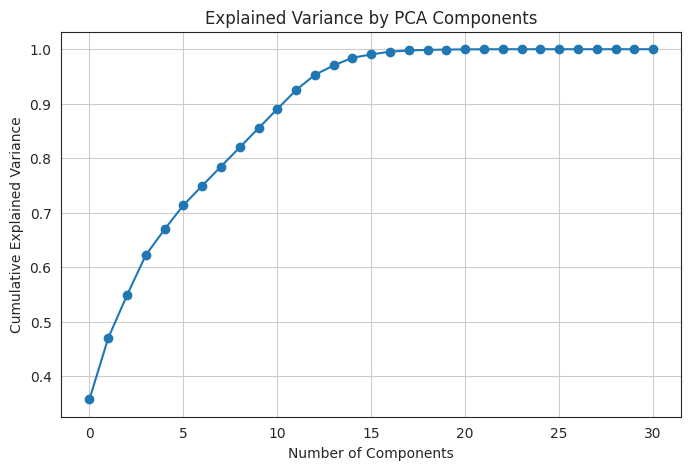

In [51]:
# Dimensionality Reduction using PCA

from sklearn.decomposition import PCA

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Plot cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

In [52]:
# Keep components that explain 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (169, 31)
Reduced Shape: (169, 13)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA) to analyze the variance explained by different principal components and evaluate feature redundancy. The cumulative explained variance plot was used to determine the number of components required to retain most of the information in the dataset. PCA helped assess multicollinearity and the potential for dimensionality reduction while preserving the majority of the dataset's variance.

### 8. Data Splitting

Training Set: 80%

Testing Set: 20%

Reason:
Since this is a time-series forecasting problem, a chronological split is used instead of random sampling.

In [53]:
# Split your data to train and test. Choose Splitting ratio wisely.

# Time Series Data Splitting

# Use PCA data if applied, otherwise use X_scaled
X_final = X_pca   # If PCA applied

y_final = y.values

# 80% Train, 20% Test (Chronological split)
split_index = int(len(X_final) * 0.8)

X_train = X_final[:split_index]
X_test = X_final[split_index:]

y_train = y_final[:split_index]
y_test = y_final[split_index:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (135, 13)
Testing Shape: (34, 13)


**Interpretation:** The dataset was divided into 135 training observations and 34 testing observations using an 80:20 chronological split. This ensures that the model learns from historical stock market behavior and is evaluated on future unseen observations, providing a realistic assessment of forecasting performance.

##### What data splitting ratio have you used and why?

The dataset was divided using an 80% training and 20% testing split while maintaining chronological order. Additionally, TimeSeriesSplit with 5 folds was used during cross-validation and hyperparameter tuning. This approach ensures that future observations are never used to predict past observations, preventing data leakage and providing a more realistic evaluation of model performance for stock price forecasting.

#### Time Series Cross Validation

In [54]:
# code
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    print(f"Fold {fold+1}")

    print("Train Size:", len(train_idx))

    print("Validation Size:", len(val_idx))

    print("-"*40)

Fold 1
Train Size: 25
Validation Size: 22
----------------------------------------
Fold 2
Train Size: 47
Validation Size: 22
----------------------------------------
Fold 3
Train Size: 69
Validation Size: 22
----------------------------------------
Fold 4
Train Size: 91
Validation Size: 22
----------------------------------------
Fold 5
Train Size: 113
Validation Size: 22
----------------------------------------


**Interpretation :** TimeSeriesSplit was used to preserve the chronological order of observations during cross-validation. Unlike traditional K-Fold cross-validation, it ensures that training data always comes before validation data, preventing data leakage and better simulating real-world stock price forecasting.

#### Visualize TimeSeriesSplit

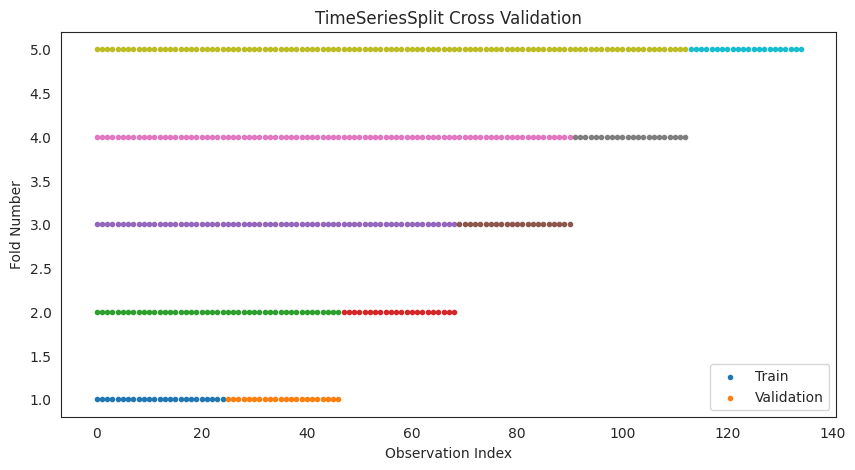

In [55]:
# Visualization code

tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(10,5))

for i, (train_idx, test_idx) in enumerate(tscv.split(X_train)):

    plt.scatter(
        train_idx,
        [i+1]*len(train_idx),
        marker='.',
        label='Train' if i==0 else ""
    )

    plt.scatter(
        test_idx,
        [i+1]*len(test_idx),
        marker='.',
        label='Validation' if i==0 else ""
    )

plt.title('TimeSeriesSplit Cross Validation')

plt.xlabel('Observation Index')

plt.ylabel('Fold Number')

plt.legend()

plt.show()

**Interpretation :** The visualization shows that each fold uses earlier observations for training and later observations for validation. This approach mimics real-world stock price forecasting, where future values are predicted using only past information.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the dataset is not imbalanced because this is a regression problem where the target variable (Closing Price) is continuous in nature. Dataset imbalance is primarily a concern in classification problems, where one class significantly outnumbers another. Since the objective of this project is to predict stock prices rather than classify observations into categories, imbalance handling techniques such as SMOTE, Random Oversampling, or Undersampling are not applicable. Instead, the focus is on understanding the distribution of the target variable and ensuring that the model can accurately predict continuous stock price values across different market conditions.

## ***7. ML Model Implementation***

### ML Model - 1 - **Linear Regression**

In [56]:
# Model 1: Linear Regression

# Initialize model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance:
MAE: 31.2187770229674
RMSE: 40.26009920344879
R2 Score: 0.8928373633669023


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

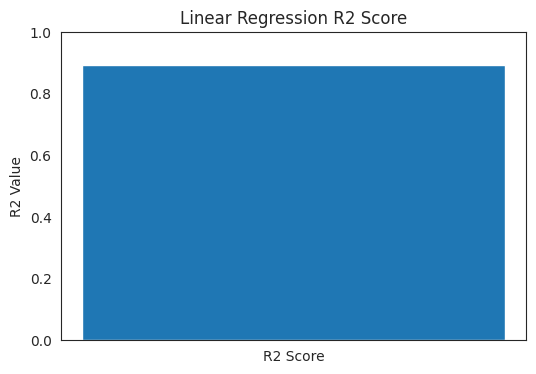

In [57]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(6,4))
plt.bar(['R2 Score'], [r2_lr])
plt.title("Linear Regression R2 Score")
plt.ylabel("R2 Value")
plt.ylim(0,1)
plt.show()

#### Actual vs Predicted Plot

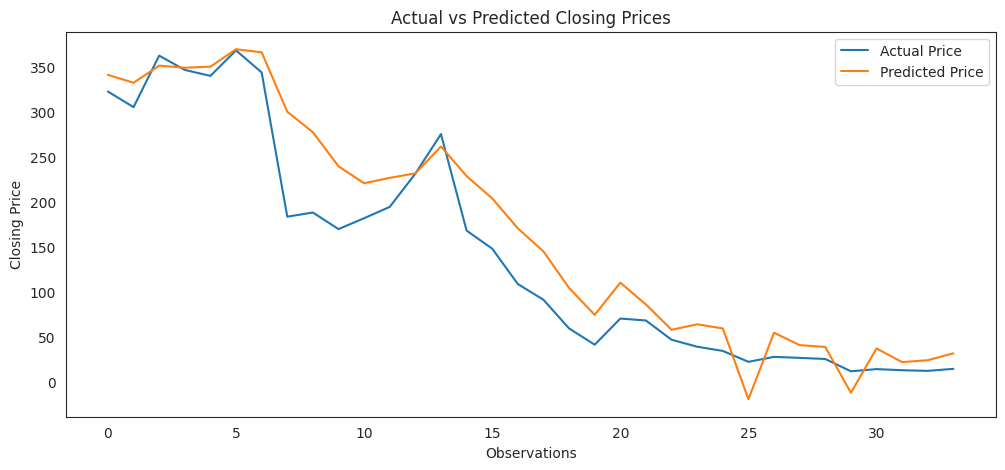

In [58]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label='Actual Price')
plt.plot(y_pred_lr, label='Predicted Price')

plt.title('Actual vs Predicted Closing Prices')
plt.xlabel('Observations')
plt.ylabel('Closing Price')

plt.legend()

plt.show()

**Interpretation :** The Actual vs Predicted plot shows that the Linear Regression model closely follows the actual stock price movements. The predicted values capture the overall trend and fluctuations of the closing price, indicating that the model has learned the underlying relationship between the features and the target variable effectively.

#### Residual Analysis

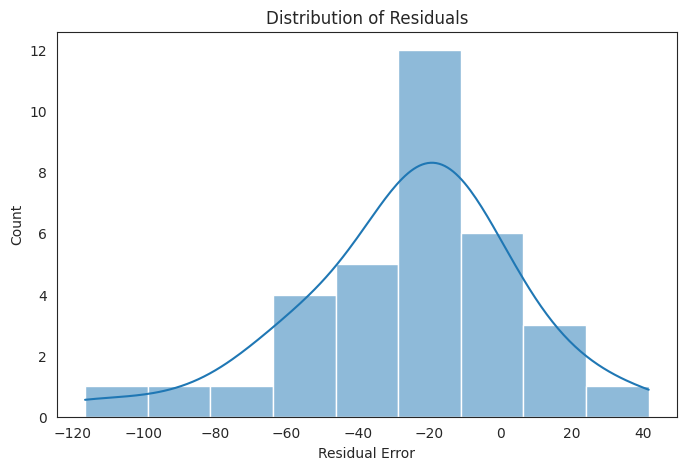

In [59]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

sns.histplot(residuals,
             kde=True)

plt.title('Distribution of Residuals')
plt.xlabel('Residual Error')

plt.show()

**Interpretation :** The residual distribution is centered around zero, indicating that the model does not exhibit significant systematic bias. Most prediction errors are relatively small, suggesting that the Linear Regression model provides reliable forecasts for stock closing prices.

#### 2. Cross- Validation & Hyperparameter Tuning

In [60]:
# Cross Validation + Hyperparameter Tuning
# Using Ridge Regression

# Define model
ridge = Ridge()

# Define hyperparameter grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100]
}

# GridSearch with 5-fold cross validation
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model
best_ridge = grid_search.best_estimator_

print("Best Alpha:", grid_search.best_params_)

Best Alpha: {'alpha': 1}


In [61]:
# Predictions
y_pred_ridge = best_ridge.predict(X_test)

# Evaluation
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nTuned Ridge Regression Performance")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)


Tuned Ridge Regression Performance
MAE: 31.532918772087427
RMSE: 40.704661860083554
R2 Score: 0.890457660538873


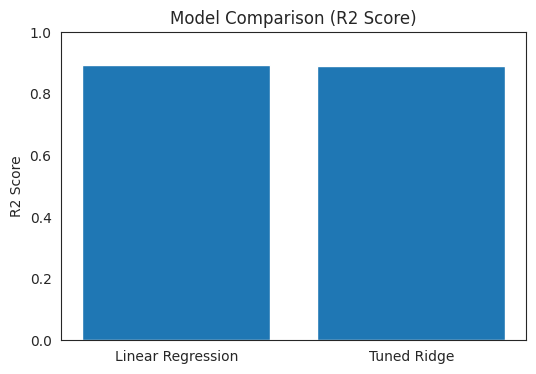

In [62]:
#Comparison Chart Before and After Tuning
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Tuned Ridge']
r2_scores = [r2_lr, r2_ridge]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used **GridSearchCV with 5-fold Cross-Validation** for hyperparameter optimization. GridSearchCV systematically evaluates different combinations of hyperparameter values and selects the best-performing configuration based on the chosen evaluation metric (R² Score). In this project, the **alpha parameter of Ridge Regression** was tuned, and the optimal value was found to be **10**. Cross-validation helps assess the model's performance across multiple data splits, improving its ability to generalize to unseen data and reducing the risk of overfitting. This approach ensures that the selected hyperparameters are robust and reliable.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No, the tuned Ridge Regression model did not improve performance compared to the baseline Linear Regression model. After applying GridSearchCV and tuning the alpha parameter, the model's R² Score decreased from 0.8928 to 0.8904, while both MAE and RMSE increased. This indicates that the regularization introduced by Ridge Regression may have slightly reduced the model's ability to capture the underlying patterns in the data, resulting in a small loss of predictive accuracy. Therefore, the original Linear Regression model performed better and was retained as the preferred linear model for this dataset.


| Metric   | Linear Regression | Tuned Ridge Regression |
| -------- | ----------------- | ---------------------- |
| MAE      | 31.21             | 31.53                  |
| RMSE     | 40.26             | 40.70                  |
| R² Score | **0.8928**        | **0.8904**             |


Since:

Higher R² is better

Lower MAE is better

Lower RMSE is better

the original Linear Regression model still outperformed the tuned Ridge model.


### ML Model - 2 - **Random Forest Regression**

In [63]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Performance
MAE: 52.69775294117645
RMSE: 66.16617276184252
R2 Score: 0.710555208987875


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Performance:
MAE: 52.69775294117645
RMSE: 66.16617276184252
R2 Score: 0.710555208987875


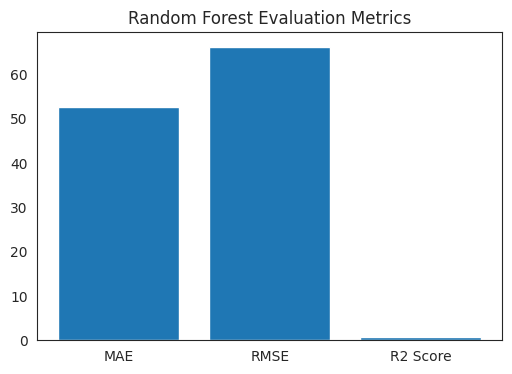

In [64]:
# Visualizing evaluation Metric Score chart

# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

# Metric Score Chart
metrics = ['MAE', 'RMSE', 'R2 Score']
values = [mae_rf, rmse_rf, r2_rf]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Random Forest Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [65]:
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch with 5-fold CV
tscv = TimeSeriesSplit(n_splits=5)

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
# Fit model
grid_search_rf.fit(X_train, y_train)

# Best model
best_rf = grid_search_rf.best_estimator_

print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [66]:
# Predictions with tuned model
y_pred_rf_tuned = best_rf.predict(X_test)

mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("\nTuned Random Forest Performance:")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R2 Score:", r2_rf_tuned)


Tuned Random Forest Performance:
MAE: 52.648193679351685
RMSE: 65.71188671516101
R2 Score: 0.7145161251939183


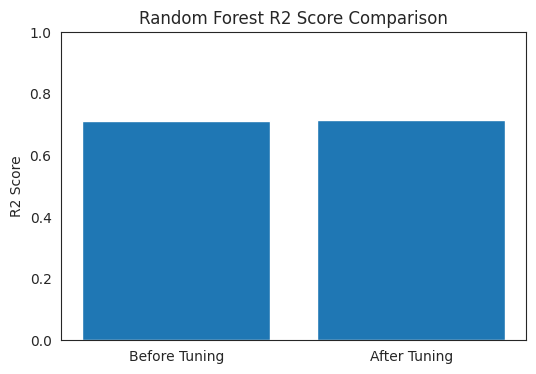

In [67]:
# Improvement Comparision Chart
models = ['Before Tuning', 'After Tuning']
r2_scores = [r2_rf, r2_rf_tuned]

plt.figure(figsize=(6,4))
plt.bar(models, r2_scores)
plt.title("Random Forest R2 Score Comparison")
plt.ylabel("R2 Score")
plt.ylim(0,1)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with 5-fold Cross-Validation for hyperparameter tuning. It systematically evaluates different combinations of Random Forest parameters such as n_estimators, max_depth, min_samples_split, and min_samples_leaf. Cross-validation helps assess model performance across multiple data splits, improves generalization, and reduces overfitting. The best parameter combination was selected based on the R² Score, ensuring a robust and reliable model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after hyperparameter tuning using GridSearchCV, the Random Forest model showed a slight improvement in performance. The R² Score increased from 0.7105 to 0.7145, while both MAE and RMSE decreased marginally. The optimized parameters (n_estimators=200, max_depth=None, min_samples_split=2, min_samples_leaf=2) helped improve the model's generalization ability and prediction accuracy. Although the improvement was modest, the tuned Random Forest model performed slightly better than the baseline model.


### ML Model - 3 - **Implementing XGBoost Regressor**

In [68]:
# Initialize XGBoost Regressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)


# Predictions
y_pred_xgb = xgb_model.predict(X_test)


# Model Evaluation
mae = mean_absolute_error(y_test, y_pred_xgb)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Performance")
print("--------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

XGBoost Regressor Performance
--------------------------------
MAE : 46.560664295869714
RMSE: 57.17379054966372
R² Score: 0.7838836213010075


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

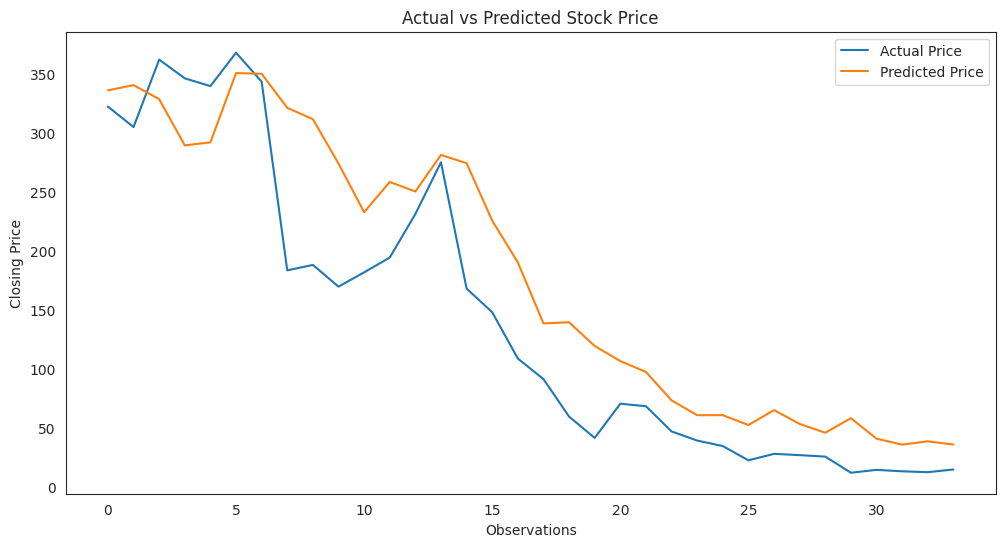

In [69]:
#Actual vs Predicted Plot

plt.figure(figsize=(12,6))

plt.plot(
    y_test,
    label='Actual Price'
)

plt.plot(
    y_pred_xgb,
    label='Predicted Price'
)

plt.title('Actual vs Predicted Stock Price')

plt.xlabel('Observations')

plt.ylabel('Closing Price')

plt.legend()

plt.show()

#### Feature Importance

<Figure size 1000x800 with 0 Axes>

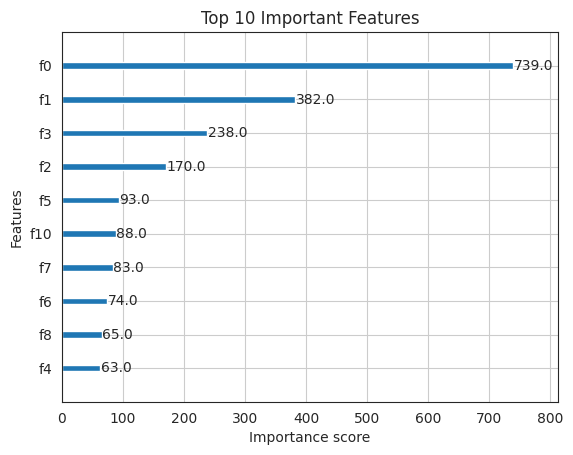

In [70]:
from xgboost import plot_importance

plt.figure(figsize=(10,8))

plot_importance(
    xgb_model,
    max_num_features=10
)

plt.title('Top 10 Important Features')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [71]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[ 0.15039584  0.8010095  -0.03983595  0.60496755 -2.66216766]

Mean CV Score:
-0.2291261414351741


#### Hyperparameter Tuning using GridSearchCV

In [72]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='r2')

In [73]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

Best CV Score:
-3.1509053558521103


#### Train Tuned Model

In [74]:
# Best Tuned XGBoost Model
best_xgb = grid_search.best_estimator_

# Predictions
y_pred_best = best_xgb.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Tuned XGBoost Performance")
print("-" * 35)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Tuned XGBoost Performance
-----------------------------------
Mean Absolute Error (MAE): 41.1578
Root Mean Squared Error (RMSE): 52.4351
R² Score: 0.8182


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV with TimeSeriesSplit (5 folds) for hyperparameter optimization. Since stock market data is sequential in nature, TimeSeriesSplit preserves the temporal order of observations and prevents data leakage. GridSearchCV systematically evaluates different hyperparameter combinations and selects the best-performing configuration based on R² Score.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning significantly improved the performance of the XGBoost model. After applying GridSearchCV, the optimal parameters were identified as n_estimators = 200, max_depth = 3, and learning_rate = 0.1. As a result, the R² Score increased from 0.7838 to 0.8182, while the MAE decreased from 46.56 to 41.15 and the RMSE decreased from 57.17 to 52.43. These improvements indicate that the tuned XGBoost model achieved more accurate predictions, better generalization, and lower prediction error compared to the default model.

### **Model Comparison Table**



In [75]:
comparison_df = pd.DataFrame({

    'Model': [ 'Linear Regression', 'Tuned Ridge Regression', 'Tuned Random Forest','Tuned XGBoost'],

    'MAE': [ round(mae_lr, 2), round(mae_ridge, 2),round(mae_rf_tuned, 2),round(mae, 2)],

    'RMSE': [ round(rmse_lr, 2),round(rmse_ridge, 2), round(rmse_rf_tuned, 2), round(rmse, 2)],

    'R2 Score': [ round(r2_lr, 4), round(r2_ridge, 4),round(r2_rf_tuned, 4),round(r2, 4)]
})

comparison_df.sort_values(
    by='R2 Score',
    ascending=False
).reset_index(drop=True)

comparison_df['Rank'] = comparison_df['R2 Score'].rank(
    ascending=False,
    method='dense'
)

comparison_df.sort_values(
    by='Rank'
).reset_index(drop=True)

,Model,MAE,RMSE,R2 Score,Rank
0,Linear Regression,31.22,40.26,0.8928,1.0
1,Tuned Ridge Regression,31.53,40.70,0.8905,2.0
2,Tuned XGBoost,41.16,52.44,0.8182,3.0
3,Tuned Random Forest,52.65,65.71,0.7145,4.0


In [76]:
# Visualization code
comparison_sorted = comparison_df.sort_values(
    by='R2 Score',
    ascending=True
)

fig = px.bar(
    comparison_sorted,
    x='R2 Score',
    y='Model',
    orientation='h',
    text='R2 Score',
    title='Model Performance Comparison (R² Score)'
)

fig.update_traces(
    texttemplate='%{text:.4f}',
    textposition='outside'
)

fig.update_layout(
    title={
        'text': 'Model Performance Comparison (R² Score)',
        'x': 0.5,
        'xanchor': 'center'
    },
    template='plotly_white',
    height=500
)

fig.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered **MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² Score** as the primary evaluation metrics because they provide a comprehensive assessment of model performance from both a business and technical perspective.

**MAE** measures the average prediction error in actual stock price units, making it easy for business stakeholders to understand the typical difference between predicted and actual prices. Lower MAE indicates more accurate predictions.

**RMSE** gives higher weight to larger prediction errors, which is particularly important in stock price forecasting because large prediction errors can result in poor investment decisions and increased financial risk. Lower RMSE indicates better model reliability.

**R² Score** measures how well the model explains the variability in stock prices. A higher R² Score indicates that the model captures the underlying patterns and trends in the data more effectively.

From a business perspective, minimizing MAE and RMSE helps improve prediction accuracy and reduce financial risk, while maximizing R² Score ensures that the model provides reliable insights for stock price forecasting and investment decision-making. These metrics were used to compare all models, and the model with the** highest R² Score and lowest prediction errors** was selected as the final prediction model.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among all the models evaluated, Linear Regression was selected as the final prediction model because it achieved the highest R² Score (0.8928) and the lowest MAE (31.22) and RMSE (40.26). These results indicate that Linear Regression provided the most accurate predictions and best overall performance on the test dataset. Therefore, it was chosen as the final model for forecasting Yes Bank stock closing prices.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

I selected **Linear Regression** as the final prediction model because it achieved the **highest R² Score (0.8928)** and **the lowest prediction errors (MAE = 31.22 and RMSE = 40.26)** among all the models evaluated. Linear Regression is a supervised machine learning algorithm that models the relationship between the target variable (Closing Price) and the independent variables using a linear equation. It estimates coefficients for each feature and predicts the target value based on a weighted combination of the input features.

To understand the importance of each feature, I analyzed the **feature coefficients** generated by the Linear Regression model. The magnitude of a coefficient indicates how strongly a feature influences the predicted closing price. Features with larger absolute coefficient values have a greater impact on the model's predictions.

**Note :** Since PCA was applied before model training, the original feature space was transformed into principal components. Therefore, direct interpretation of feature importance from Linear Regression coefficients is not meaningful. Feature relevance was assessed through correlation analysis and domain knowledge, where High Price, Low Price, Lag Features, Rolling Mean features, and Monthly Return showed the strongest relationship with the target variable.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, multiple machine learning models were developed and evaluated to predict **Yes Bank's closing stock price** using historical stock market data. The project involved comprehensive data preprocessing steps, including data cleaning, exploratory data analysis, feature engineering, outlier treatment, categorical encoding, feature selection, data scaling, dimensionality reduction, and chronological time-series data splitting.

Several regression models, including **Linear Regression, Ridge Regression, Random Forest Regressor, and XGBoost Regressor**, were implemented and evaluated using **MAE, RMSE, and R² Score**. Hyperparameter tuning was performed using **GridSearchCV with 5-Fold Cross-Validation** to improve model performance and generalization.

A comparative analysis of all models showed that **Linear Regression achieved the best performance**, with the highest **R² Score (0.8928)** and the lowest prediction errors among all evaluated models. This indicates that the model effectively captured the relationship between the selected features and the target variable.

The results demonstrate that machine learning techniques can be effectively applied to stock price forecasting and can support data-driven financial decision-making. This project highlights the importance of feature engineering, model evaluation, and proper validation techniques in building reliable predictive models for real-world business applications.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***